# Lab 4.1: Xây dựng ANN với Tensorflow dự đoán Churn Customer
**Người thực hiện:** Triệu Minh Trí
**Đề tài:** Dự đoán khả năng rời bỏ dịch vụ của khách hàng (Customer Churn) bằng mạng nơ-ron nhân tạo (Artificial Neural Network) sử dụng thư viện TensorFlow và Keras.


In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

print("TensorFlow Version:", tf.__version__)


/Users/huythanh/Code/TriMT/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


Matplotlib is building the font cache; this may take a moment.


TensorFlow Version: 2.20.0


## 1. Tiền xử lý dữ liệu (Data Preprocessing)
Đọc dữ liệu từ file `Churn_Modelling.csv` được tải từ Kaggle.


In [2]:
# Đọc dữ liệu từ file CSV
dataset = pd.read_csv('Churn_Modelling.csv')
dataset.head()


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [3]:
# Hiển thị thông tin tổng quan về tập dữ liệu
dataset.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


Tách các cột không cần thiết như `RowNumber`, `CustomerId`, `Surname` và lấy biến phụ thuộc `Exited` (biến đích biểu thị khách hàng rời đi hay ở lại).


In [4]:
X = dataset.drop(labels=['CustomerId', 'Surname', 'RowNumber', 'Exited'], axis=1)
y = dataset['Exited']
X.head()


,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,619,France,Female,42,2,0.00,1,1,1,101348.88
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58
2,502,France,Female,42,8,159660.80,3,1,0,113931.57
3,699,France,Female,39,1,0.00,2,0,0,93826.63
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10


Mã hóa các cột dạng phân loại (categorical variables) gồm `Geography` (Quốc gia) và `Gender` (Giới tính) sử dụng `LabelEncoder`.


In [5]:
# Khởi tạo và mã hóa cột Geography
label_geo = LabelEncoder()
X['Geography'] = label_geo.fit_transform(X['Geography'])

# Khởi tạo và mã hóa cột Gender
label_gender = LabelEncoder()
X['Gender'] = label_gender.fit_transform(X['Gender'])

X.head()


,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,619,0,0,42,2,0.00,1,1,1,101348.88
1,608,2,0,41,1,83807.86,1,0,1,112542.58
2,502,0,0,42,8,159660.80,3,1,0,113931.57
3,699,0,0,39,1,0.00,2,0,0,93826.63
4,850,2,0,43,2,125510.82,1,1,1,79084.10


Do quốc gia (`Geography`) có 3 nhóm giá trị, sau khi Label Encoding, ta thực hiện One-Hot Encoding sử dụng `pd.get_dummies` với tham số `drop_first=True` để tránh bẫy đa cộng tuyến (Dummy Variable Trap).


In [6]:
X = pd.get_dummies(X, drop_first=True, columns=['Geography'])
X.head()


,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_1,Geography_2
0,619,0,42,2,0.00,1,1,1,101348.88,False,False
1,608,0,41,1,83807.86,1,0,1,112542.58,False,True
2,502,0,42,8,159660.80,3,1,0,113931.57,False,False
3,699,0,39,1,0.00,2,0,0,93826.63,False,False
4,850,0,43,2,125510.82,1,1,1,79084.10,False,True


Chia tập dữ liệu thành tập huấn luyện (80%) và tập kiểm tra (20%), phân tầng (stratify) dựa trên biến đích `y` để đảm bảo tỷ lệ nhãn cân đối.


In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0, stratify=y)
print("Kích thước tập Train:", X_train.shape)
print("Kích thước tập Test:", X_test.shape)


Kích thước tập Train: (8000, 11)
Kích thước tập Test: (2000, 11)


Chuẩn hóa các đặc trưng (Feature Scaling) bằng `StandardScaler` để đưa các giá trị về cùng một phân phối chuẩn có trung bình là 0 và độ lệch chuẩn là 1, giúp mạng ANN hội tụ nhanh hơn.


In [8]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
X_train[:3]


array([[-1.24021723, -1.09665089,  0.77986083,  0.35390313, -1.23451386,
        -0.90298067, -1.54963239, -1.03849022,  1.64099027, -0.57812007,
        -0.57504086],
       [ 0.75974873,  0.91186722, -0.27382717,  0.35390313,  0.2854211 ,
         0.81371262,  0.64531434,  0.96293637, -1.55587522,  1.72974448,
        -0.57504086],
       [-1.72725557, -1.09665089, -0.9443559 , -0.3390904 ,  0.85569573,
        -0.90298067,  0.64531434, -1.03849022,  1.1038111 , -0.57812007,
        -0.57504086]])

## 2. Xây dựng mô hình mạng ANN (Build ANN)
Khởi tạo mô hình mạng nơ-ron nhân tạo tuần tự (`Sequential`) bao gồm:
- **Lớp đầu tiên (Input & Hidden Layer 1)**: Số nút bằng kích thước đầu vào (`X.shape[1]`), hàm kích hoạt (activation function) là `relu`.
- **Lớp ẩn thứ hai (Hidden Layer 2)**: 128 nút, hàm kích hoạt `relu`.
- **Lớp đầu ra (Output Layer)**: 1 nút (do dự đoán nhị phân), hàm kích hoạt `sigmoid` để đưa ra xác suất rời bỏ dịch vụ.


In [9]:
model = Sequential()
model.add(Dense(X.shape[1], activation='relu', input_dim=X.shape[1]))
model.add(Dense(128, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

model.summary()


/Users/huythanh/Code/TriMT/.venv/lib/python3.9/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 11)             │           132 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │         1,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,797 (7.02 KB)

 Trainable params: 1,797 (7.02 KB)

 Non-trainable params: 0 (0.00 B)

Biên dịch (Compile) mô hình:
- Thuật toán tối ưu (Optimizer): `adam`
- Hàm mất mát (Loss function): `binary_crossentropy`
- Chỉ số đánh giá (Metrics): `accuracy`


In [10]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])


Huấn luyện mô hình trên tập huấn luyện (`X_train`) trong 10 epoch, batch size bằng 10, phân tách thêm 10% tập validation để theo dõi quá trình học tập.


In [11]:
history = model.fit(
    X_train, 
    y_train.to_numpy(), 
    batch_size=10, 
    epochs=10, 
    validation_split=0.1, 
    verbose=1
)


Epoch 1/10


  1/720 ━━━━━━━━━━━━━━━━━━━━ 2:49 235ms/step - accuracy: 0.6000 - loss: 0.6949

166/720 ━━━━━━━━━━━━━━━━━━━━ 0s 305us/step - accuracy: 0.7556 - loss: 0.5633  

358/720 ━━━━━━━━━━━━━━━━━━━━ 0s 281us/step - accuracy: 0.7743 - loss: 0.5243

552/720 ━━━━━━━━━━━━━━━━━━━━ 0s 274us/step - accuracy: 0.7815 - loss: 0.5067

...

  1/720 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 1.0000 - loss: 0.1800

195/720 ━━━━━━━━━━━━━━━━━━━━ 0s 259us/step - accuracy: 0.8715 - loss: 0.3167

390/720 ━━━━━━━━━━━━━━━━━━━━ 0s 258us/step - accuracy: 0.8694 - loss: 0.3202

586/720 ━━━━━━━━━━━━━━━━━━━━ 0s 257us/step - accuracy: 0.8669 - loss: 0.3252

720/720 ━━━━━━━━━━━━━━━━━━━━ 0s 296us/step - accuracy: 0.8662 - loss: 0.3272 - val_accuracy: 0.8600 - val_loss: 0.3335


## 3. Dự đoán và đánh giá hiệu năng mô hình (Evaluation)
Dự đoán xác suất cho tập kiểm tra (`X_test`) và quy về nhãn nhị phân dựa trên ngưỡng 0.5.


In [12]:
y_pred = model.predict(X_test)
y_pred = (y_pred > 0.5).astype("int32")


 1/63 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 342us/step


In [13]:
test_loss, test_acc = model.evaluate(X_test, y_test.to_numpy())
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")


 1/63 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - accuracy: 0.8125 - loss: 0.3785

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 337us/step - accuracy: 0.8512 - loss: 0.3614


Test Loss: 0.3549
Test Accuracy: 0.8565


In [14]:
# Tạo ma trận nhầm lẫn và hiển thị các chỉ số đánh giá
cm = confusion_matrix(y_test, y_pred)
acc = accuracy_score(y_test, y_pred)
print("Confusion Matrix:\n", cm)
print("Accuracy Score:", acc)
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Confusion Matrix:
 [[1550   43]
 [ 244  163]]
Accuracy Score: 0.8565

Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.97      0.92      1593
           1       0.79      0.40      0.53       407

    accuracy                           0.86      2000
   macro avg       0.83      0.69      0.72      2000
weighted avg       0.85      0.86      0.84      2000



## 4. Trực quan hóa kết quả (Data & Training Visualization)
Vẽ đồ thị lịch sử huấn luyện (Loss và Accuracy qua từng epoch) và Heatmap của Ma trận nhầm lẫn.


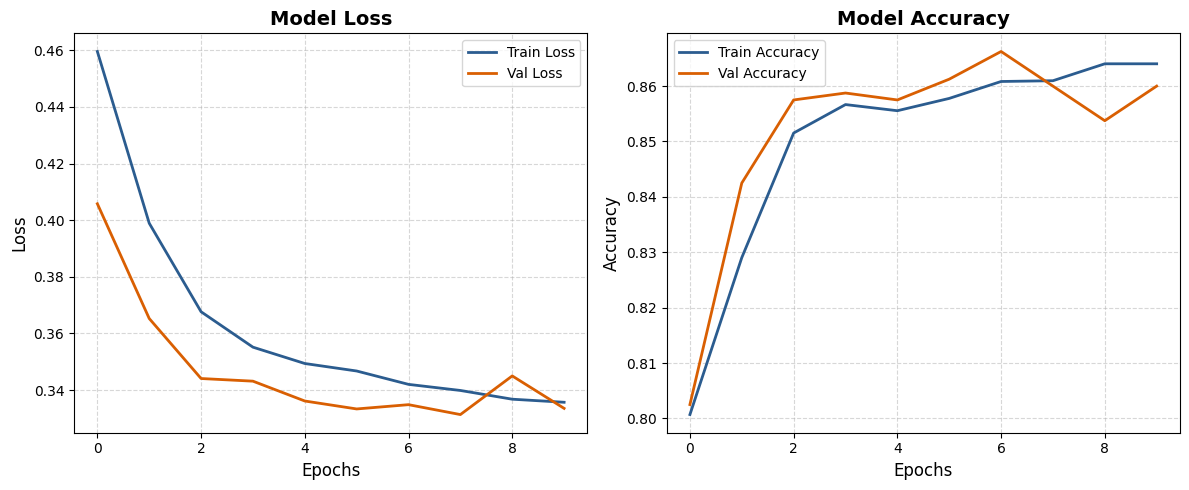

In [15]:
plt.figure(figsize=(12, 5))

# Đồ thị Loss
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss', color='#2b5c8f', lw=2)
if 'val_loss' in history.history:
    plt.plot(history.history['val_loss'], label='Val Loss', color='#d95f02', lw=2)
plt.title('Model Loss', fontsize=14, fontweight='bold')
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

# Đồ thị Accuracy
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Accuracy', color='#2b5c8f', lw=2)
if 'val_accuracy' in history.history:
    plt.plot(history.history['val_accuracy'], label='Val Accuracy', color='#d95f02', lw=2)
plt.title('Model Accuracy', fontsize=14, fontweight='bold')
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('training_history.png', dpi=300)
plt.show()


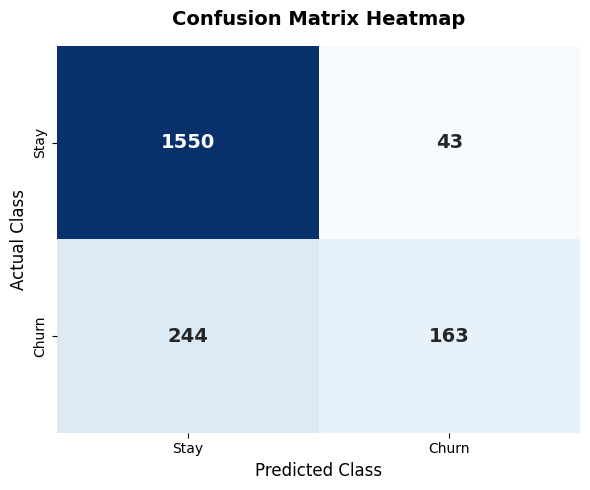

In [16]:
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Stay', 'Churn'],
            yticklabels=['Stay', 'Churn'],
            annot_kws={'size': 14, 'weight': 'bold'})
plt.title('Confusion Matrix Heatmap', fontsize=14, fontweight='bold', pad=15)
plt.ylabel('Actual Class', fontsize=12)
plt.xlabel('Predicted Class', fontsize=12)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=300)
plt.show()
